In [42]:
#DBSCAN


In [43]:
#Algorithme de clustering non supervisé qui regroupe les points proches entre eux selon une distance (eps) et un nombre minimum de voisins (min_pts),
#et détecte aussi les points bruit (outliers). Son objectif est de trouver automatiquement des groupes de formes quelconques 
#sans donner le nombre de clusters à l’avance.


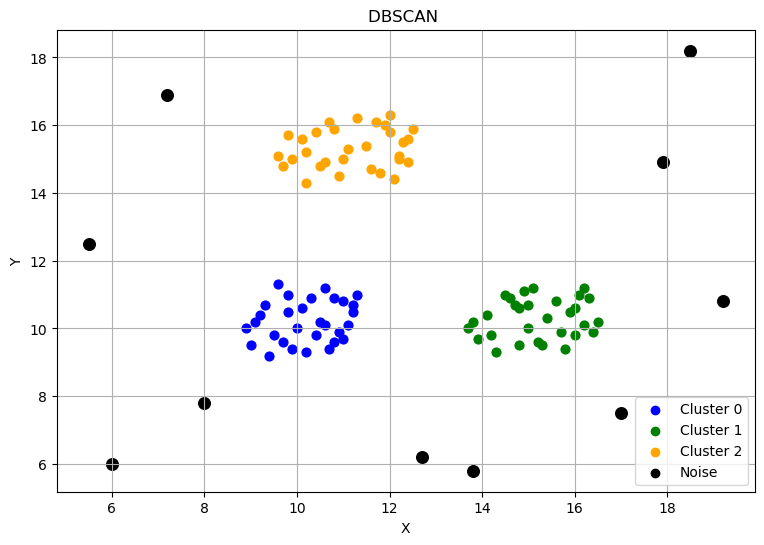

In [44]:
import numpy as np  
# bibliothèque pour les calculs mathématiques

import matplotlib.pyplot as plt  
# bibliothèque pour les graphiques


# =========================================================
# 1. DATASET
# =========================================================

# données contenant plusieurs clusters
X = np.array([

    [9.5,9.8],[10.0,10.0],[10.5,10.2],[9.2,10.4],[10.8,9.6],
    [11.0,10.8],[9.8,11.0],[10.2,9.3],[11.2,10.5],[9.0,9.5],
    [10.6,11.2],[9.3,10.7],[10.9,9.9],[9.7,9.6],[11.1,10.1],
    [8.9,10.0],[10.3,10.9],[9.6,11.3],[10.7,9.4],[11.3,11.0],
    [9.4,9.2],[10.1,10.6],[10.8,10.9],[9.1,10.2],[11.0,9.7],
    [10.4,9.8],[9.8,10.5],[10.6,10.1],[9.9,9.4],[11.2,10.7],

    [14.8,9.5],[15.0,10.0],[15.4,10.3],[16.0,10.6],[14.2,9.8],
    [15.8,9.4],[16.2,10.1],[14.6,10.9],[15.1,11.2],[13.9,9.7],
    [16.4,9.9],[14.7,10.7],[15.6,10.8],[13.8,10.2],[16.1,11.0],
    [14.3,9.3],[15.9,10.5],[16.3,10.9],[14.9,11.1],[15.2,9.6],
    [13.7,10.0],[15.0,10.7],[16.0,9.8],[14.5,11.0],[15.7,9.9],
    [16.5,10.2],[14.1,10.4],[15.3,9.5],[16.2,11.2],[14.8,10.6],

    [10.5,14.8],[11.0,15.0],[11.5,15.4],[12.0,15.8],[10.2,14.3],
    [12.2,15.1],[11.8,14.6],[10.8,15.9],[12.4,15.6],[9.9,15.0],
    [11.3,16.2],[10.6,14.9],[12.1,14.4],[9.8,15.7],[11.9,16.0],
    [10.2,15.2],[12.3,15.5],[10.7,16.1],[12.5,15.9],[9.7,14.8],
    [11.1,15.3],[10.9,14.5],[12.0,16.3],[10.4,15.8],[11.6,14.7],
    [12.2,15.0],[10.1,15.6],[11.7,16.1],[9.6,15.1],[12.4,14.9],

    [6.0,6.0],[18.5,18.2],[7.2,16.9],[17.0,7.5],[13.8,5.8],
    [5.5,12.5],[19.2,10.8],[8.0,7.8],[17.9,14.9],[12.7,6.2]
])


# =========================================================
# 2. PARAMÈTRES DBSCAN
# =========================================================

eps = 0.8  
# distance maximale entre voisins

min_pts = 4  
# nombre minimum de voisins

labels = np.full(len(X), -1)  
# tableau des labels

cluster_id = 0  
# numéro du cluster


# =========================================================
# 3. DISTANCE EUCLIDIENNE
# =========================================================

def distance(a, b):

    # calcul distance euclidienne
    return np.sqrt(
        (a[0]-b[0])**2 +
        (a[1]-b[1])**2
    )


# =========================================================
# 4. RECHERCHE DES VOISINS
# =========================================================

def get_neighbors(i):

    neighbors = []  
    # liste des voisins

    for j in range(len(X)):  
    # parcourir tous les points

        if distance(X[i], X[j]) <= eps:  
        # vérifier distance

            neighbors.append(j)  
            # ajouter voisin

    return neighbors  
    # retourner voisins


# =========================================================
# 5. ALGORITHME DBSCAN
# =========================================================

for i in range(len(X)):  
# parcourir tous les points

    if labels[i] != -1:  
    # ignorer points déjà visités
        continue

    neighbors = get_neighbors(i)  
    # récupérer voisins

    if len(neighbors) < min_pts:  
    # pas assez de voisins

        labels[i] = -1  
        # point = bruit

    else:

        labels[i] = cluster_id  
        # créer cluster

        seed = neighbors.copy()  
        # copie des voisins

        k = 0

        while k < len(seed):  
        # expansion cluster

            point = seed[k]

            labels[point] = cluster_id  
            # affecter cluster

            new_neighbors = get_neighbors(point)  
            # voisins du nouveau point

            if len(new_neighbors) >= min_pts:  
            # si point dense

                for n in new_neighbors:

                    if n not in seed:  
                    # éviter doublons

                        seed.append(n)

            k += 1

        cluster_id += 1  
        # cluster suivant




# =========================================================
# 6. VISUALISATION
# =========================================================

plt.figure(figsize=(9,6))  
# taille figure

colors = ["blue","green","orange"]  
# couleurs des clusters

for i in range(len(X)):  
# parcourir tous les points

    if labels[i] == -1:  
    # bruit

        plt.scatter(
            X[i][0],
            X[i][1],
            color="black",
            s=70
        )

    else:

        plt.scatter(
            X[i][0],
            X[i][1],
            color=colors[labels[i]],
            s=40
        )

# =========================================================
# 8.LÉGENDE UNIQUE
# =========================================================

plt.scatter([], [], color="blue", label="Cluster 0")
plt.scatter([], [], color="green", label="Cluster 1")
plt.scatter([], [], color="orange", label="Cluster 2")
plt.scatter([], [], color="black", label="Noise")

# titre
plt.title("DBSCAN ")

# axe X
plt.xlabel("X")

# axe Y
plt.ylabel("Y")

# grille
plt.grid(True)

# affichage légende
plt.legend()

# affichage final
plt.show()

In [45]:
#Naive Bays


In [46]:
# Naive Bayes est un algorithme de classification probabiliste basé sur le théorème de Bayes 
#avec l’hypothèse que toutes les variables sont indépendantes entre elles,
#son objectif est de classer rapidement les données en utilisant les probabilités.

In [47]:
import numpy as np  # bibliothèque pour manipuler les tableaux (calcul scientifique)

# ====================================
# 1. DATASET (X, y)
# ====================================

# X = matrice des features (variables explicatives)
# chaque ligne = email
# chaque colonne = feature (mot)
# 1 = mot présent, 0 = mot absent
X = np.array([
    [1, 1],  # email 1 → Free=Yes, Money=Yes → Spam
    [1, 0],  # email 2 → Free=Yes, Money=No → Spam
    [0, 0],  # email 3 → Free=No, Money=No → Not Spam
])

# y = labels (classes)
# 1 = Spam, 0 = Not Spam
# variable cible (target)
y = np.array([
    1,  # Spam
    1,  # Spam
    0   # Not Spam
])

# ====================================
# 2. NOUVEL EMAIL (X_test)
# ====================================

# x_test = observation à prédire
# vecteur des features du nouvel email
x_test = np.array([1, 0])  
# Free=Yes, Money=No

# ====================================
# 3. PRIOR PROBABILITY P(C)
# ====================================

def prior(label):

    # P(C) = probabilité a priori de la classe C
    # formule :
    # P(C) = nombre d'exemples de la classe / total des exemples

    return np.sum(y == label) / len(y)

# ====================================
# 4. LIKELIHOOD P(Xi | C) (Vraisemblance)
# ====================================

def likelihood(feature_index, value, label):

    # subset = données appartenant à la classe C
    subset = X[y == label]

    # count = nombre d'occurrences de la valeur dans cette classe
    count = np.sum(subset[:, feature_index] == value)

    # total = nombre total d'exemples dans la classe C
    total = len(subset)

    # formule :
    # P(xi | C) = count / total
    return count / total

# ====================================
# 5. FORMULE NAIVE BAYES
# ====================================

# FORMULE GLOBALE :
# P(Ck | X) ∝ P(Ck) × Π P(xi | Ck)
# VARIABLES :
# - Ck = classe (0 ou 1)
# - X = vecteur des features
# - xi = chaque feature
# - Π = produit de toutes les probabilités

# on multiplie la probabilité de la classe avec toutes les probabilités des features

classes = [0, 1]  # toutes les classes possibles

best_class = None   # classe finale prédite
best_prob = -1      # meilleure probabilité trouvée

# ====================================
# 6. PRÉDICTION
# ====================================

for c in classes:

    # P(Ck) → probabilité de la classe
    p = prior(c)

    # affichage de la classe actuelle
    print(f"\nClasse {c}")

    # multiplication des P(xi | Ck)
    for i in range(len(x_test)):

        # valeur de la feature i
        value = x_test[i]

        # P(xi | Ck)
        p_feature = likelihood(i, value, c)

        print(f"P(x{i} | C{c}) = {p_feature}")

        # Naive Bayes :
        # indépendance des features → multiplication
        p *= p_feature

    # résultat final de la formule :
    # P(Ck | X) ∝ P(Ck) × Π P(xi | Ck)
    print(f"> P(C{c} | X) ∝ {p}")

    # choix du maximum
    if p > best_prob:
        best_prob = p
        best_class = c

# ====================================
# 7. RÉSULTAT FINAL
# ====================================

# classe avec la probabilité la plus élevée

if best_class == 1:
    print("\n -->Résultat : SPAM ")
else:
    print("\n -->Résultat : NOT SPAM ")


Classe 0
P(x0 | C0) = 0.0
P(x1 | C0) = 1.0
> P(C0 | X) ∝ 0.0

Classe 1
P(x0 | C1) = 1.0
P(x1 | C1) = 0.5
> P(C1 | X) ∝ 0.3333333333333333

 -->Résultat : SPAM 
